<center>
<img src="https://raw.githubusercontent.com/FUlyankin/r_probability/master/end_seminars_2020/sem08/real_expect.png" width="500">

# Домашнее задание 7: тесты о математически ожиданиях
</center>

**ФИО:** Гаврин Глеб Юрьевич

## Общая информация

- [Лекция о точных тестах](https://youtu.be/PLrHmjw0EG0)
- [Лекция о тесте Уэлча](https://youtu.be/S52tY1h8nBE)
- Полезные блокноты: [тетрадка 1](https://github.com/FUlyankin/matstat-AB/blob/main/week09_hypo/10_13_python_mouse_and_man.ipynb) и [тетрадка 2](https://github.com/FUlyankin/matstat-AB/blob/main/week09_hypo/14_python_dependent.ipynb)

__Дата выдачи:__ 01.06.2024

__Дедлайн:__ 23:59MSK 20.06.2024

In [1]:
import numpy as np
import pandas as pd

from scipy import stats as sts

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')
%matplotlib inline

 ### Задача 1: экзамен

<center>
<img src="https://github.com/FUlyankin/yet_another_matstat_course/blob/main/hw_2024/images/exam.jpeg?raw=true" width="400">
</center>
<br>


У вас есть набор данных об оценках студентов на экзамене. Каждая строка в датасете – отдельный студент. Датасет представляет собой следующие колонки:

* `gender` – пол
* `race/ethnicity` – раса / этническая принадлежность
* `parental level of education` – уровень образования
* `lunch` – получает ли бесплатные обеды (тип питания)
* `test preparation course` – прошел ли курсы по подготовке к тесту
* `math score` – баллы за математику
* `reading score` – баллы за чтение
* `writing score` – баллы за письменность

In [2]:
df = pd.read_csv('students_exam.csv')
print(df.shape)
df.head()

(1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


__а)__ __[4 балла]__  Проверьте гипотезу о том, что студенты, получившие высшее образование (associate's degree, bachelor's degree, master's degree) в среднем пишут математику на большее число баллов, чем студенты со средним образованием (high school, some high school, some college). 

Уровень значимости: $5\%$

$$
\begin{aligned}
& H_0: \mu_{high} = \mu_{middle} \\
& H_1: \mu_{high} > \mu_{middle}
\end{aligned}
$$

__Подсказка:__ В тесте 2 выборки: студенты с высшим образованием и со средним. Подумайте о том, как эти выборки связаны между собой. Также обратите внимание на альтернативную гипотезу!

In [5]:
df['higher_educ'] = np.where(df['parental level of education'].isin(["bachelor's degree", "master's degree", "associate's degree"]), 1, 0)

Выыборки представляют собой разных студентов, поэтому они незавимсимы

## Проверка предпосылок ассимптотических тестов

### Много наблюдений

In [12]:
# 1000 наблюдений - это достаточно много, для того, чтобы работала ассимптотика

### Отсутствие выбросов

In [10]:
df['math score'].describe()

# балл по математике всегда принадлежит диапазону [0, 100], поэтому выбросов, которые ломают предпосылки ассимптотических тестов, здесь нет

count    1000.00000
mean       66.08900
std        15.16308
min         0.00000
25%        57.00000
50%        66.00000
75%        77.00000
max       100.00000
Name: math score, dtype: float64

### Проверка на нормальность распределения

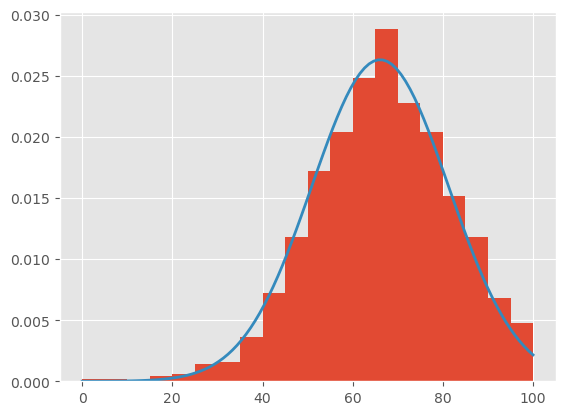

In [16]:
plt.hist(df['math score'], density=True, bins=20)

xs = np.linspace(0,100,100)
pdf = sts.norm(df['math score'].mean(), df['math score'].std(ddof=1)).pdf(xs)
plt.plot(xs, pdf, lw=2)
plt.show()

# распределение очень похоже на нормальное (усеченное нормальное), проверим это еще и тестом Колмогорова-Смирнова

In [18]:
sts.kstest(df['math score'], 'norm', args=(df['math score'].mean(), df['math score'].std(ddof=1)))
# p-value > 0.05 => гипотеза о нормальности не отвергается

KstestResult(statistic=0.030855239411150426, pvalue=0.29095203837537353, statistic_location=58, statistic_sign=-1)

In [19]:
# посмотрим на средние баллы у людей с высшим и средним образованием
university = df[(df['higher_educ'] == 1)]['math score'].dropna().values
college = df[(df['higher_educ'] == 0)]['math score'].dropna().values

university.mean(), college.mean()

(68.60401002506266, 64.41930116472545)

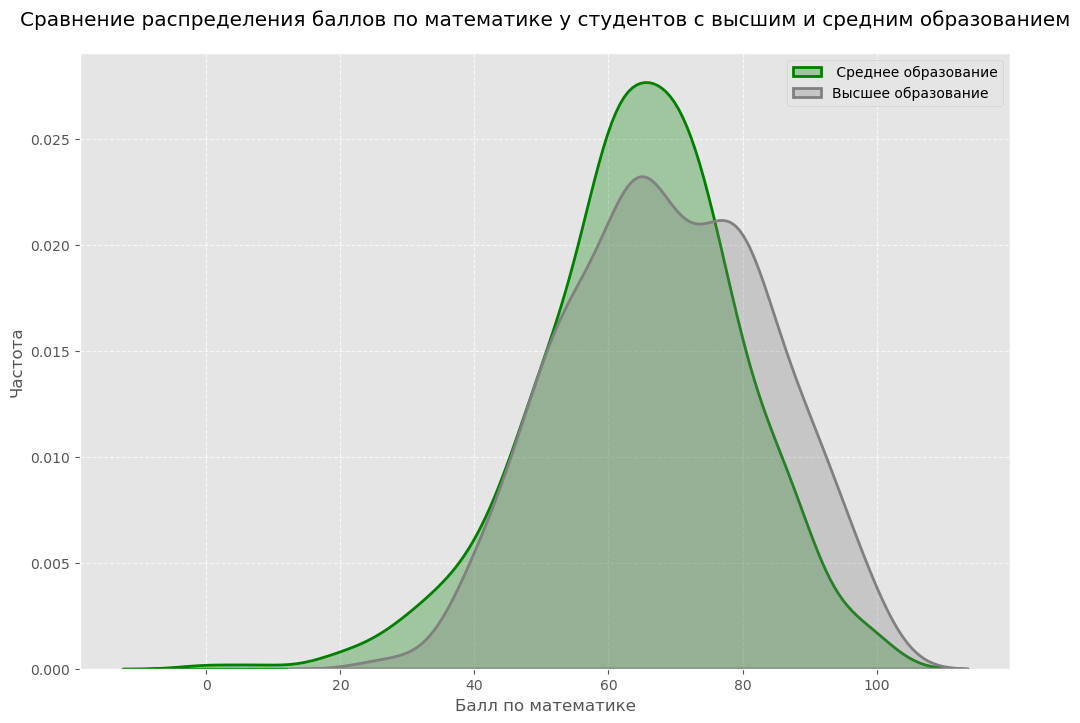

In [20]:

plt.figure(figsize=(12, 8), dpi=100)
sns.kdeplot(
    data=college,
    color="green",
    label=" Среднее образование",
    linewidth=2,
    fill=True,
    alpha=0.3,
)

sns.kdeplot(
    data=university,
    color="grey",
    label="Высшее образование",
    linewidth=2,
    fill=True,
    alpha=0.3,
)

plt.title("Сравнение распределения баллов по математике у студентов с высшим и средним образованием", pad=20)
plt.xlabel("Балл по математике")
plt.ylabel("Частота")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.7)

plt.show()

### Сравнение дисперсий

In [ ]:
university.var(), college.var()
# дисперсии очень схожи. Проведем еще на всякий случай тест на их равенство

(226.02364306756868, 225.13533461978233)

In [24]:
alpha = 0.05                             
nx, ny = university.size, college.size   # размер выборок

F_obs = university.var()/college.var()   # наблюдаемое значение

f_rv = sts.f(nx - 1, ny - 1) 
F_crit = f_rv.ppf(1 - alpha/2)           # критическое значение

print(f'Наблюдаемое значение {F_obs:.5} меньше критического {F_crit:.5} => нулевая гипотеза не отвергается => равенство дисперсий не отвергается')

Наблюдаемое значение 1.0039 меньше критического 1.1945 => нулевая гипотеза не отвергается => равенство дисперсий не отвергается


Так как: 

0) Выборки независимы 
1) Распределения нормальные 
2) Наблюдений много 
3) Дисперсии выборок равны

Наилучшим выбором будет **тест Стьюдента**


In [33]:
from statsmodels.stats.weightstats import ttest_ind

t_obs, p_val, _ = ttest_ind(university, college, value=0, alternative='larger')

print(f"Наблюдаемое значение: {t_obs:.3}") 
print(f"P-значение: {round(p_val, 8)}")

Наблюдаемое значение: 4.31
P-значение: 8.93e-06


In [ ]:
round(p_val, 8) < 0.05
# p-value < уровня значимости => нулевая гипотеза отвергается

True

Студенты, получившие высшее образование (associate's degree, bachelor's degree, master's degree) в среднем пишут математику **на большее число баллов**, чем студенты со средним образованием (high school, some high school, some college).

__Почему вы выбрали для проверки гипотезы именно тот критерий, что вы выбрали? Какие у него предпосылки? Все ли они выполняются с данными?__

__Ответ:__ ответил выше

__б)__ __[3 балла]__  Правда ли что в среднем студенты пишут экзамен по `reading` так же, как и по `math`? 

Уровень значимости: $5\%$

$$
\begin{aligned}
& H_0: \mu_{math} = \mu_{reading} \\
& H_1: \mu_{math} \neq \mu_{reading}
\end{aligned}
$$

__Подсказка:__ В тесте 2 выборки: баллы по чтению и баллы по математике. Подумайте о том, как эти выборки связаны между собой. Также обратите внимание на альтернативную гипотезу!

Выборки **связаны**, так как тесты по чтению и математике пишут одни и те же студенты

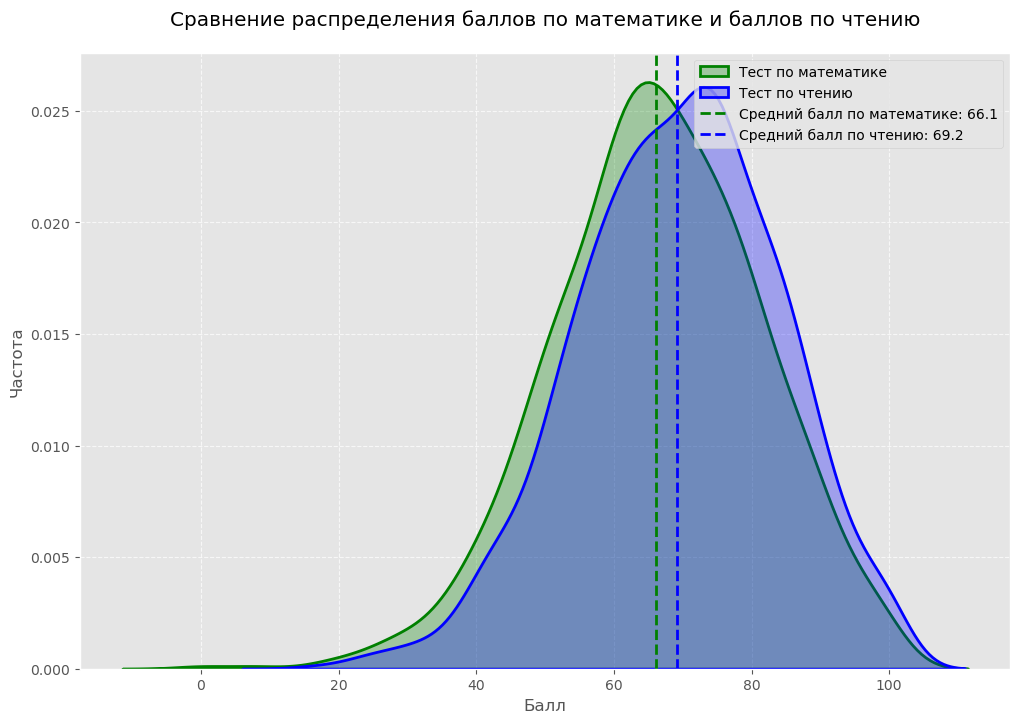

In [37]:
plt.figure(figsize=(12, 8), dpi=100)
sns.kdeplot(
    data=df['math score'],
    color="green",
    label="Тест по математике",
    linewidth=2,
    fill=True,
    alpha=0.3,
)

sns.kdeplot(
    data=df['reading score'],
    color="blue",
    label="Тест по чтению",
    linewidth=2,
    fill=True,
    alpha=0.3,
)

plt.axvline(df['math score'].mean(), color='green', linestyle='--', linewidth=2, 
            label=f'Средний балл по математике: {df['math score'].mean():.1f}')
plt.axvline(df['reading score'].mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Средний балл по чтению: {df['reading score'].mean():.1f}')

plt.title("Сравнение распределения баллов по математике и баллов по чтению", pad=20)
plt.xlabel("Балл")
plt.ylabel("Частота")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.7)

plt.show()

Визуально кажется, что средние значительно отличаются. Проверим, статистически значимо ли это различие.

В такой задаче удобнее работать с разностью баллов. Вычислим её 

In [38]:
diff_math_reading = df['reading score'] - df['math score']

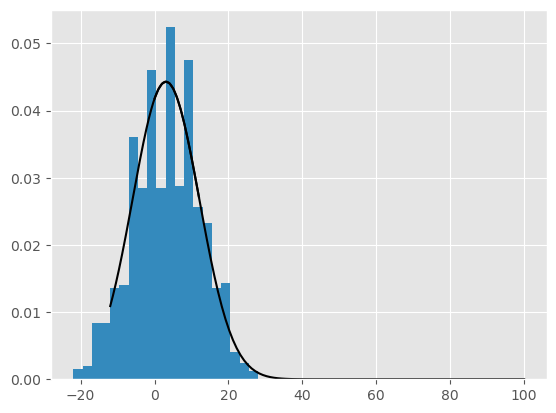

In [40]:
# посмотрим на распределение разности средних

diff_math_reading_mean = diff_math_reading.mean()
diff_math_reading_std = diff_math_reading.std(ddof=1)

plt.hist(diff_math_reading, bins=20, density=True)

xs = np.linspace(0, 100, 100)
ys = sts.norm(loc=diff_math_reading_mean, scale=diff_math_reading_std).pdf(xs)
plt.plot(xs, ys, color="black")
plt.show()

In [41]:
# распределение похоже на нормальное. Проверим ещё и тестом Колмогорова-Смирнова

sts.kstest(diff_math_reading_mean, 'norm', args=(diff_math_reading_mean, diff_math_reading_std))
# p-value > 0.05 => гипотеза о нормальности не отвергается

KstestResult(statistic=0.5, pvalue=1.0, statistic_location=3.08, statistic_sign=-1)

Данные распределены нормально => **можем использовать тест Стьюдента**

In [48]:
sts.ttest_1samp(diff_math_reading, 0, alternative='greater')[1] < 0.05

True

p-value < уровня значимости => гипотеза о равенстве мат ожиданий баллов по математике и чтению отвергается в пользу альтернативы что **мат ожидание балла по чтению выше мат ожидания балла по математике**

__в)__ __[3 балла]__ Почему вы выбрали для проверки гипотезы именно тот критерий, что вы выбрали? Какие у него предпосылки? Все ли они выполняются с данными?

__Ответ:__ Я выбрал этот критерий исходя из его предпосылок.

**Предпосылки:** нормальность распределения разности баллов, независимость студентов друг от друга.\
С этими данными они выполняются, только если студенты не списывали друг у друга, тогда ломается независимость :)